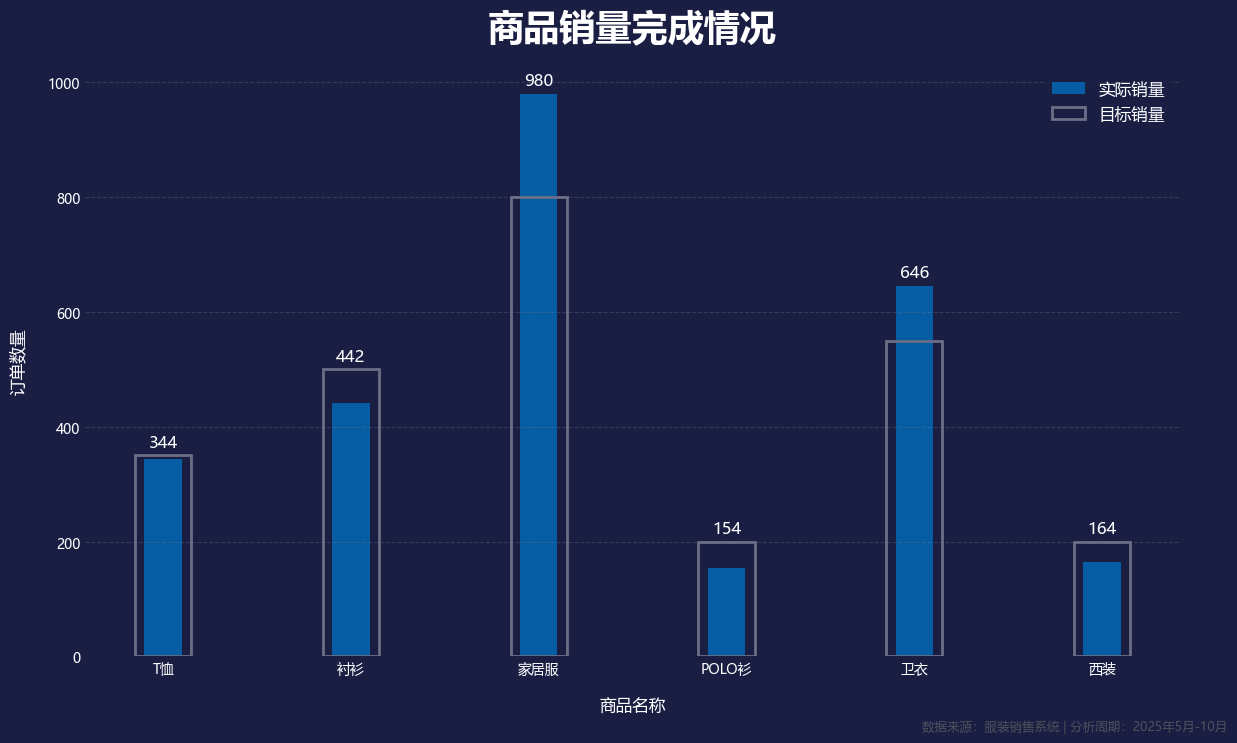

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取新的数据文件
    df = pd.read_csv("../../数据生成/erp_order.csv", encoding='utf-8-sig')
    
    # 验证必需字段
    required_columns = ['商品名称']
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"数据缺失必要字段: {', '.join(missing_cols)}")
    
    # 筛选所需的商品数据，包含特定关键词
    target_keywords = ['T恤', '衬衫', '家居服', 'POLO衫', '卫衣', '西装']
    filter_condition = df['商品名称'].str.contains('|'.join(target_keywords), na=False)
    df = df[filter_condition]
    
    # 检查数据完整性
    if df.empty:
        raise ValueError("过滤后的订单数据为空")
    
    # 定义目标销量
    target_sales = {
        'T恤': 350,
        '衬衫': 500,
        '家居服': 800,
        'POLO衫': 200,
        '卫衣': 550,
        '西装': 200
    }
    
    # 图表设置
    fig, ax = plt.subplots(figsize=(12, 8), dpi=100)
    fig.patch.set_facecolor('#1A1E43')  # 深色背景
    ax.set_facecolor('#1A1E43')
    
    # 隐藏坐标轴边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 商品名称的计数
    category_colors = dict(zip(target_keywords, ['#016dbc'] * len(target_keywords)))
    
    # 计算各商品的订单总数，按目标关键词匹配
    product_counts = df['商品名称'].apply(lambda name: next((kw for kw in target_keywords if kw in name), None)).value_counts().reindex(target_keywords, fill_value=0)
    
    # 绘制实际销量
    ax.bar(product_counts.index, product_counts.values, color='#016dbc', label='实际销量', alpha=0.8, width=0.2, align='center')
    
    # 绘制目标销量
    ax.bar(target_sales.keys(), target_sales.values(), color='none', edgecolor='#6b6e85', linewidth=2, label='目标销量', width=0.3, align='center')

    # 添加标题和标签
    plt.title("商品销量完成情况", fontsize=26, fontweight="bold", color="#ffffff", pad=20)
    plt.xlabel("商品名称", fontsize=12, color="#ffffff", labelpad=15)
    plt.ylabel("订单数量", fontsize=12, color="#ffffff", labelpad=15)
    
    # 添加数据来源说明
    plt.figtext(
        0.9, 0.03,
        '数据来源：服装销售系统 | 分析周期：2025年5月-10月',
        ha='center', fontsize=9, color='#666666', alpha=0.7
    )
    
    # 设定X轴刻度和标签
    ax.set_xticks(range(len(target_keywords)))
    ax.set_xticklabels(target_keywords, ha='center', color='#ffffff')
    
    # 隐藏刻度线
    ax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='y', which='both', length=0)
    ax.xaxis.set_tick_params(colors='#ffffff')
    ax.yaxis.set_tick_params(colors='#ffffff')
    
    # 添加数据标签
    for index, (actual, target) in enumerate(zip(product_counts.values, target_sales.values())):
        # 判断实际销量是否小于目标销量
        if actual < target:
            # 标签在目标销量柱体上方
            ax.text(index, target + 15, f'{actual}', color='white', ha='center', fontsize=12)
        else:
            # 标签在实际销量柱体上方
            ax.text(index, actual + 15, f'{actual}', color='white', ha='center', fontsize=12)
    
    # 图例
    ax.legend(facecolor='#1A1E43', edgecolor='none', fontsize=12, loc='upper right', labelcolor='white')
    
    # 添加网格线
    ax.grid(axis='y', linestyle="--", alpha=0.3, color='#777b92')
    ax.grid(axis='x', visible=False)
    
    # 设定Y轴刻度和标签
    ax.set_yticks(np.arange(0, product_counts.max()+200, 200))
    
    # 调整布局
    plt.tight_layout(rect=(0, 0.03, 1, 0.95))
    
    # 保存图表
    plt.savefig(
        "商品销量完成情况.png",
        dpi=300,
        bbox_inches='tight',
        facecolor=fig.get_facecolor()
    )
    
    # 显示图表
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **T恤**：
  - 目标销量：350件
  - 实际销量：344件
  - 完成率：98.2%，接近目标销量，表现良好。

- **衬衫**：
  - 目标销量：500件
  - 实际销量：442件
  - 完成率：88.4%，略低于目标，需关注市场需求变化。

- **家居服**：
  - 目标销量：800件
  - 实际销量：980件
  - 完成率：122.5%，显著超出目标，显示出强劲的市场需求。

- **POLO衫**：
  - 目标销量：200件
  - 实际销量：154件
  - 完成率：77.0%，未达到目标，需评估市场策略。

- **卫衣**：
  - 目标销量：550件
  - 实际销量：646件
  - 完成率：117.5%，超过目标，表现优异。

- **西装**：
  - 目标销量：200件
  - 实际销量：164件
  - 完成率：82.0%，略高于目标，表现稳定。


# 结论

从商品销量完成情况来看，家居服和卫衣类别超额完成目标，显示出较高的市场需求和良好的销售策略。T恤和西装类别接近目标，表现良好。衬衫和POLO衫类别未达到目标，需进一步分析原因并调整策略。